In [1]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.decomposition import IncrementalPCA
import matplotlib.pyplot as plt


Transformed data first 5 rows
[[-2.68398205  0.3198167 ]
 [-2.71392719 -0.17974508]
 [-2.88904582 -0.14381661]
 [-2.74552819 -0.31647778]
 [-2.72872873  0.32928425]]


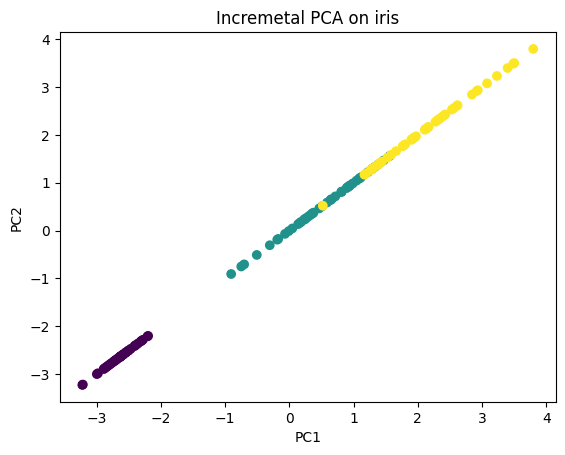

In [12]:
# Load the dataset
data = load_iris()
X = data.data
y = data.target

# Split into batches 
batches = np.array_split(X , 3)

# Creeate Incremental PCA model
ipca = IncrementalPCA(n_components = 2)

# Incrementalally fit model
for batch in batches :
    ipca.partial_fit(batch)

# transform the entire dataset
X_ipca = ipca.transform(X)

# Print transformed samples
print("Transformed data first 5 rows")
print(X_ipca[:5])

# Plot the result
plt.scatter(X_ipca[:,0] , X_ipca[:,0] , c=y)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Incremetal PCA on iris")
plt.show()

In [11]:
print("Explained variance ratio:", ipca.explained_variance_ratio_)


Explained variance ratio: [0.92369191 0.05292581]


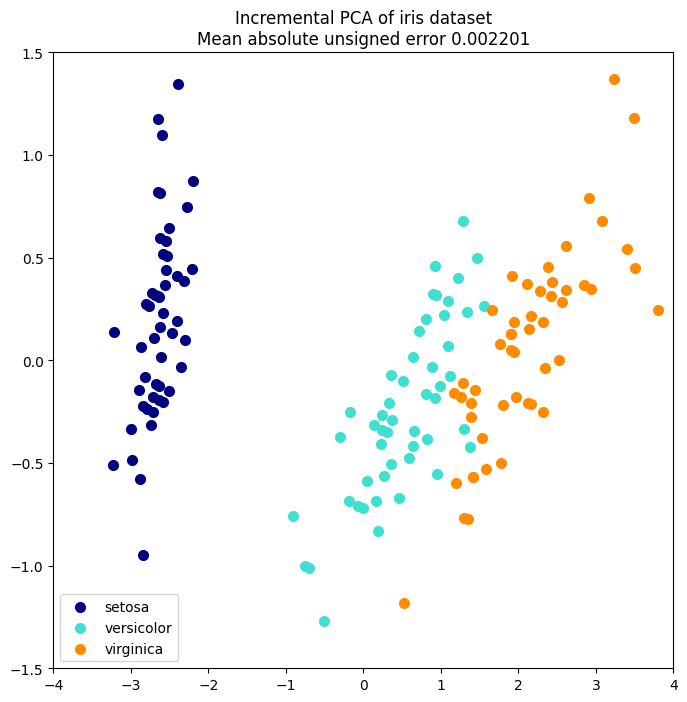

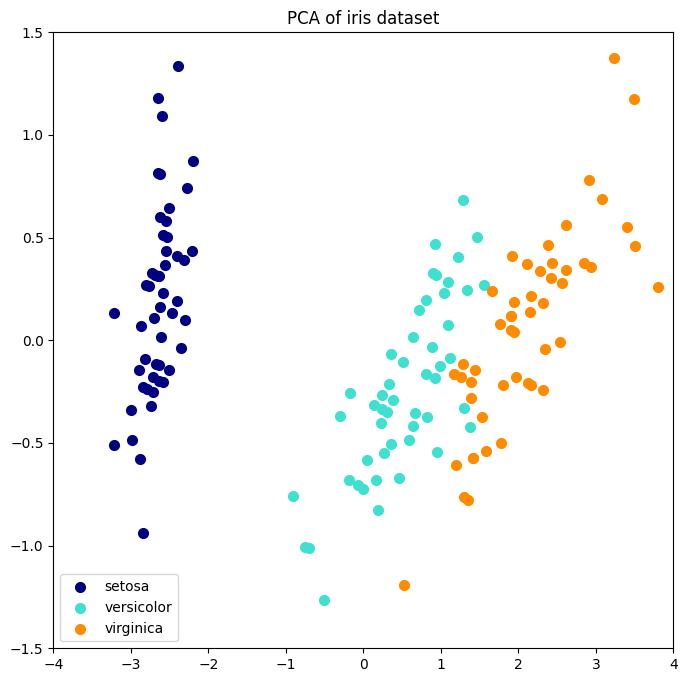

In [13]:
# Authors: The scikit-learn developers
# SPDX-License-Identifier: BSD-3-Clause

import matplotlib.pyplot as plt
import numpy as np

from sklearn.datasets import load_iris
from sklearn.decomposition import PCA, IncrementalPCA

iris = load_iris()
X = iris.data
y = iris.target

n_components = 2
ipca = IncrementalPCA(n_components=n_components, batch_size=10)
X_ipca = ipca.fit_transform(X)

pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X)

colors = ["navy", "turquoise", "darkorange"]

for X_transformed, title in [(X_ipca, "Incremental PCA"), (X_pca, "PCA")]:
    plt.figure(figsize=(8, 8))
    for color, i, target_name in zip(colors, [0, 1, 2], iris.target_names):
        plt.scatter(
            X_transformed[y == i, 0],
            X_transformed[y == i, 1],
            color=color,
            lw=2,
            label=target_name,
        )

    if "Incremental" in title:
        err = np.abs(np.abs(X_pca) - np.abs(X_ipca)).mean()
        plt.title(title + " of iris dataset\nMean absolute unsigned error %.6f" % err)
    else:
        plt.title(title + " of iris dataset")
    plt.legend(loc="best", shadow=False, scatterpoints=1)
    plt.axis([-4, 4, -1.5, 1.5])

plt.show()